### **Yogyakarta's Air Quality Dataset in August 2021**

In [1]:
import pandas as pd

df = pd.read_csv("08-jogja-aug-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,8/1/2021,00:00:00,10.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
2,8/1/2021,01:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
3,8/1/2021,02:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
4,8/1/2021,03:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
5,8/1/2021,04:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,8/31/2021,19:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
741,8/31/2021,20:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
742,8/31/2021,21:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
743,8/31/2021,22:00:00,16.0,32.0,NaN,9.0,NaN,3.0,32,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 08-jogja-aug-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                723 non-null    float64
 3   PM2.5               723 non-null    float64
 4   SO2                 0 non-null      float64
 5   CO                  723 non-null    float64
 6   O3                  0 non-null      float64
 7   NO2                 723 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  723 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 08-jogja-aug-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,723.000000,723.000000,0.0,723.000000,0.0,723.000000,744.000000
mean,16.333333,32.390041,NaN,3.795297,NaN,2.800830,31.475806
std,7.437893,11.635270,NaN,2.794857,NaN,0.675367,12.663656
min,6.000000,14.000000,NaN,0.000000,NaN,1.000000,0.000000
25%,11.000000,23.000000,NaN,1.000000,NaN,2.000000,23.000000
50%,15.000000,30.000000,NaN,3.000000,NaN,3.000000,30.000000
75%,19.000000,38.000000,NaN,5.000000,NaN,3.000000,38.000000
max,48.000000,68.000000,NaN,12.000000,NaN,5.000000,68.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 08-jogja-aug-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 08-jogja-aug-2021.csv


Category
Good        89.247312
Moderate    10.752688
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 08-jogja-aug-2021.csv


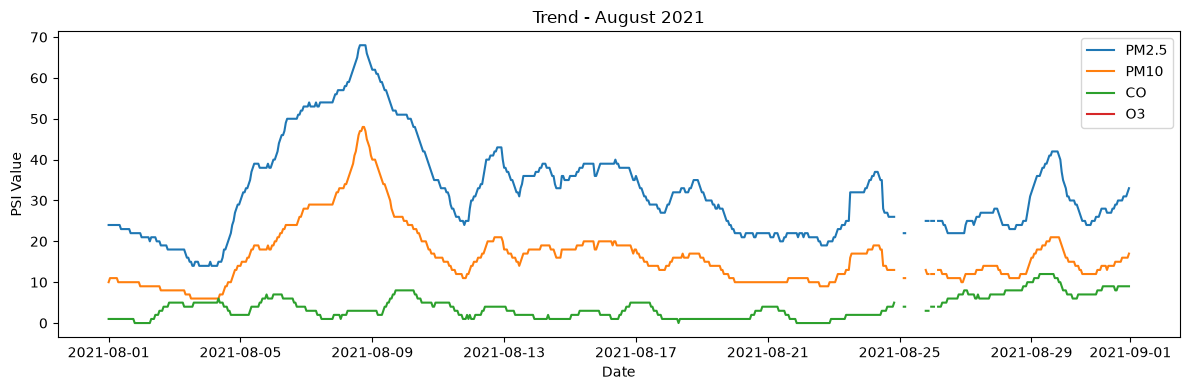

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - August 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In August 2021, PM2.5 was the highest and peaked at about 68 around August 8, and PM10 and CO followed the same up and down pattern. O3 has no line because there is no data, and there are a few short gaps near the end of the month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 08-jogja-aug-2021.csv


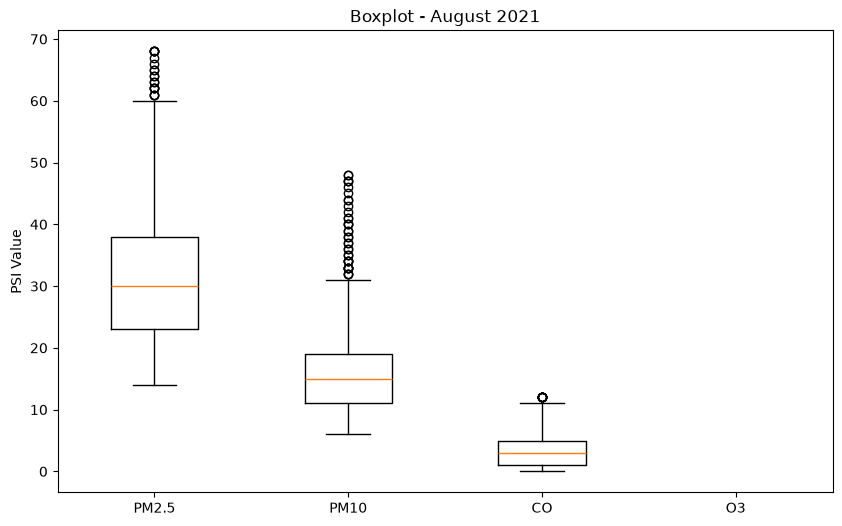

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - August 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In August 2021, PM2.5 had the highest median (30), and PM2.5 and PM10 had many high outliers, while CO had only a few, O3 has no box because there is no data.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 08-jogja-aug-2021.csv


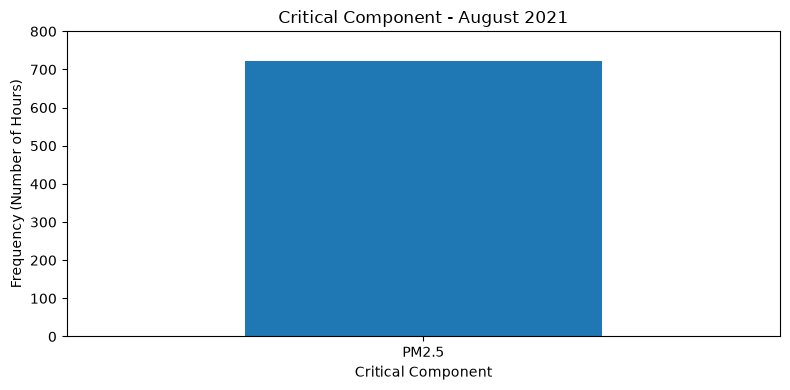

Critical Component
PM2.5    723
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - August 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 08-jogja-aug-2021.csv


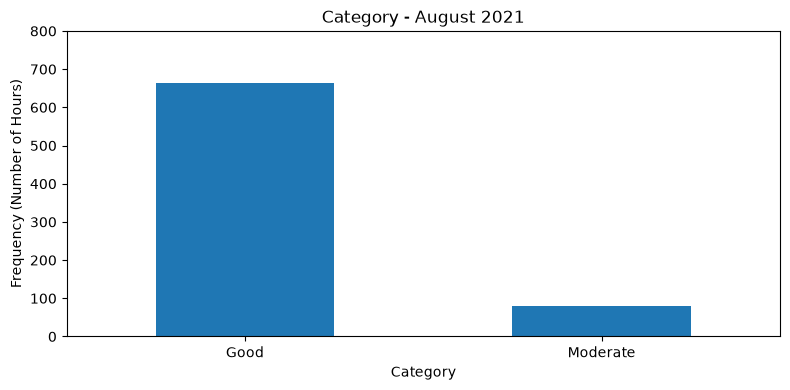

Category
Good        664
Moderate     80
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - August 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category